# Análisis demográfico — Censo Argentina 2022

Este notebook calcula indicadores de población a partir del Censo 2022 (INDEC):
- Población total de Argentina
- Población por provincia
- Distribución por sexo (nacional y por provincia)
- Grupos de edad (nacionales y por provincia)
- Todo lo anterior abierto por sexo donde es posible

> **Nota técnica:** Los datos están en formato largo pre-agregado por radio censal. Sexo y edad son variables **separadas** en la base — no existe una variable cruzada edad × sexo en este dataset. Por eso en la sección de grupos de edad se muestran ambas dimensiones por separado.

In [2]:
pip install matplotlib

  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------- ----------- 5.8/8.1 MB 29.3 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 27.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 33.2 MB/s eta 0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import censoargentino as censo
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Estilo de gráficos
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Colores por sexo
COLOR_MUJER = "#e07b8a"
COLOR_VARON = "#5b8ec4"
COLOR_TOTAL = "#4a4a6a"

print("OK")

OK


---
## 1. Descarga de datos nacionales

Descargamos dos variables para todo el país:
- `PERSONA_P02` → sexo (nos da la población total y la distribución por sexo)
- `PERSONA_EDADGRU` → grupos de edad grandes (0-14, 15-64, 65+)

⏱️ Sin filtro de provincia estas consultas tardan entre 10 y 30 segundos.

In [4]:
# Sexo — todo el país
df_sexo = censo.query(variables="PERSONA_P02")
print(f"Filas: {len(df_sexo):,}")

[ciut] =======================================================
[ciut] Consulta al Censo Nacional 2022 (INDEC)
[ciut] Fuente: censo-2022-largo.parquet (~2.1 GB total en S3)
[ciut]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[ciut] -------------------------------------------------------
[ciut]   Variable : PERSONA_P02
[ciut] -------------------------------------------------------
[ciut] Estructura del resultado:
[ciut]   Cada fila = una (radio censal × categoría de variable × conteo)
[ciut]   Columnas clave: id_geo | codigo_variable | valor_categoria
[ciut]                   etiqueta_categoria | conteo
[ciut] =======================================================
[ciut] Descargando datos desde S3...
[ciut] Iniciando DuckDB e instalando extensión HTTP...
[ciut] Listo. Las consultas se hacen directo al bucket S3 de INDEC/CIUT.
[ciut] Descarga completa en 4.5s -> 132,571 filas | 13 columnas | 84.2 MB en memoria
Filas: 132,571


In [5]:
# Grupos de edad — todo el país
df_edad = censo.query(variables="PERSONA_EDADGRU")
print(f"Filas: {len(df_edad):,}")

[ciut] =======================================================
[ciut] Consulta al Censo Nacional 2022 (INDEC)
[ciut] Fuente: censo-2022-largo.parquet (~2.1 GB total en S3)
[ciut]   (DuckDB descarga solo los bloques que coinciden con los filtros)
[ciut] -------------------------------------------------------
[ciut]   Variable : PERSONA_EDADGRU
[ciut] -------------------------------------------------------
[ciut] Estructura del resultado:
[ciut]   Cada fila = una (radio censal × categoría de variable × conteo)
[ciut]   Columnas clave: id_geo | codigo_variable | valor_categoria
[ciut]                   etiqueta_categoria | conteo
[ciut] =======================================================
[ciut] Descargando datos desde S3...
[ciut] Descarga completa en 4.8s -> 197,412 filas | 13 columnas | 127.0 MB en memoria
Filas: 197,412


---
## 2. Población total de Argentina

Sumando el `conteo` de ambas categorías de sexo (Mujer + Varón) obtenemos el total de personas.

In [6]:
POB_TOTAL = df_sexo["conteo"].sum()
print(f"Población total Argentina (Censo 2022): {POB_TOTAL:,}")

Población total Argentina (Censo 2022): 45,618,787


In [7]:
# Distribución por sexo — nacional
sexo_pais = (
    df_sexo
    .groupby("etiqueta_categoria")["conteo"]
    .sum()
    .rename("personas")
    .reset_index()
    .rename(columns={"etiqueta_categoria": "sexo"})
)
sexo_pais["pct"] = (sexo_pais["personas"] / POB_TOTAL * 100).round(1)
sexo_pais

,sexo,personas,pct
0,Mujer / Femenino,23607906,51.8
1,Varón / Masculino,22010881,48.2


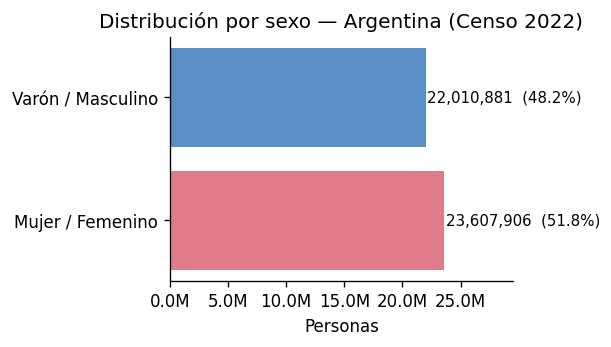

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
colores = [COLOR_MUJER, COLOR_VARON]
barras = ax.barh(sexo_pais["sexo"], sexo_pais["personas"], color=colores)

for bar, row in zip(barras, sexo_pais.itertuples()):
    ax.text(bar.get_width() + 100_000, bar.get_y() + bar.get_height()/2,
            f"{row.personas:,.0f}  ({row.pct}%)", va="center", fontsize=9)

ax.set_xlabel("Personas")
ax.set_title("Distribución por sexo — Argentina (Censo 2022)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_xlim(0, sexo_pais["personas"].max() * 1.25)
plt.tight_layout()
plt.show()

---
## 3. Población por provincia

In [9]:
# Población total por provincia (suma Mujer + Varón)
pob_prov = (
    df_sexo
    .groupby("etiqueta_provincia")["conteo"]
    .sum()
    .sort_values(ascending=False)
    .rename("poblacion")
    .reset_index()
    .rename(columns={"etiqueta_provincia": "provincia"})
)
pob_prov["pct_pais"] = (pob_prov["poblacion"] / POB_TOTAL * 100).round(1)
pob_prov

,provincia,poblacion,pct_pais
0,Buenos Aires,17408906,38.2
1,Córdoba,3812064,8.4
2,Santa Fe,3519059,7.7
3,Caba,3095454,6.8
4,Mendoza,2030773,4.5
5,Tucumán,1727337,3.8
6,Salta,1434225,3.1
7,Entre Ríos,1415097,3.1
8,Misiones,1273347,2.8
9,Corrientes,1209671,2.7


In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
pob_ord = pob_prov.sort_values("poblacion")
ax.barh(pob_ord["provincia"], pob_ord["poblacion"], color=COLOR_TOTAL, alpha=0.85)

for _, row in pob_ord.iterrows():
    ax.text(row["poblacion"] + 30_000, pob_ord.index[pob_ord["provincia"] == row["provincia"]].tolist()[0] - pob_ord.index[0],
            f"{row['poblacion']/1e6:.2f}M  ({row['pct_pais']}%)", va="center", fontsize=8)

ax.set_xlabel("Población")
ax.set_title("Población por provincia — Argentina (Censo 2022)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_xlim(0, pob_ord["poblacion"].max() * 1.3)
plt.tight_layout()
plt.show()

---
## 4. Población por provincia, abierta por sexo

In [ ]:
# Tabla: provincia × sexo
sexo_prov = (
    df_sexo
    .groupby(["etiqueta_provincia", "etiqueta_categoria"])["conteo"]
    .sum()
    .unstack("etiqueta_categoria")
    .fillna(0)
    .astype(int)
)
sexo_prov.columns.name = None
sexo_prov["Total"] = sexo_prov.sum(axis=1)
sexo_prov = sexo_prov.sort_values("Total", ascending=False)
sexo_prov

In [ ]:
# Índice de feminidad: mujeres por cada 100 varones
col_mujer = "Mujer / Femenino"
col_varon = "Varón / Masculino"

fem_idx = (
    (sexo_prov[col_mujer] / sexo_prov[col_varon] * 100)
    .round(1)
    .rename("mujeres_por_100_varones")
    .reset_index()
    .rename(columns={"etiqueta_provincia": "provincia"})
    .sort_values("mujeres_por_100_varones", ascending=False)
)
fem_idx

In [ ]:
# Gráfico: % mujeres por provincia
pct_mujer_prov = (
    (sexo_prov[col_mujer] / sexo_prov["Total"] * 100)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 8))
colores_barra = [COLOR_MUJER if v >= 50 else COLOR_VARON for v in pct_mujer_prov]
ax.barh(pct_mujer_prov.index, pct_mujer_prov.values, color=colores_barra, alpha=0.85)
ax.axvline(50, color="grey", linestyle="--", linewidth=0.8, label="50%")

for prov, val in pct_mujer_prov.items():
    ax.text(val + 0.1, list(pct_mujer_prov.index).index(prov),
            f"{val:.1f}%", va="center", fontsize=8)

ax.set_xlabel("% mujeres sobre el total")
ax.set_title("% Mujeres por provincia — Argentina (Censo 2022)")
ax.set_xlim(45, 55)
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Grupos de edad — nacional

In [ ]:
# Verificar etiquetas reales de PERSONA_EDADGRU
censo.describe("PERSONA_EDADGRU")

In [ ]:
# Total por grupo de edad — nacional
# Ordenamos por valor_categoria (1, 2, 3) para mantener orden correcto
edad_pais = (
    df_edad
    .groupby(["valor_categoria", "etiqueta_categoria"])["conteo"]
    .sum()
    .reset_index()
    .sort_values("valor_categoria")
    .rename(columns={"etiqueta_categoria": "grupo_edad", "conteo": "personas"})
)
edad_pais["pct"] = (edad_pais["personas"] / edad_pais["personas"].sum() * 100).round(1)
edad_pais

In [ ]:
fig, ax = plt.subplots(figsize=(6, 3.5))
colores_edad = ["#69b3a2", "#5b8ec4", "#e07b8a"]
barras = ax.bar(edad_pais["grupo_edad"], edad_pais["personas"],
                color=colores_edad, alpha=0.85, width=0.5)

for bar, row in zip(barras, edad_pais.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100_000,
            f"{row.personas/1e6:.2f}M\n({row.pct}%)",
            ha="center", fontsize=9)

ax.set_ylabel("Personas")
ax.set_title("Distribución por grandes grupos de edad — Argentina (Censo 2022)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M"))
ax.set_ylim(0, edad_pais["personas"].max() * 1.25)
plt.tight_layout()
plt.show()

---
## 6. Grupos de edad por provincia

In [ ]:
# Tabla: provincia × grupo de edad
edad_prov = (
    df_edad
    .groupby(["etiqueta_provincia", "valor_categoria", "etiqueta_categoria"])["conteo"]
    .sum()
    .reset_index()
    .sort_values(["etiqueta_provincia", "valor_categoria"])
    .pivot_table(
        index="etiqueta_provincia",
        columns="etiqueta_categoria",
        values="conteo",
        aggfunc="sum"
    )
    .fillna(0)
    .astype(int)
)
edad_prov.columns.name = None
edad_prov["Total"] = edad_prov.sum(axis=1)
edad_prov

In [ ]:
# Porcentaje por grupo de edad por provincia
edad_prov_pct = (
    edad_prov.drop(columns="Total")
    .div(edad_prov["Total"], axis=0)
    .mul(100)
    .round(1)
)
edad_prov_pct

In [ ]:
# Provincias con mayor % de adultos mayores (65+)
col_65 = [c for c in edad_prov_pct.columns if "65" in c][0]
print("Columna adultos mayores:", col_65)

ranking_65 = edad_prov_pct[col_65].sort_values(ascending=False).reset_index()
ranking_65.columns = ["provincia", "pct_65_mas"]
ranking_65

In [ ]:
# Gráfico: distribución de grupos de edad por provincia (barras apiladas)
cols_orden = sorted(
    [c for c in edad_prov_pct.columns],
    key=lambda c: df_edad.loc[df_edad["etiqueta_categoria"] == c, "valor_categoria"].min()
)

plot_data = edad_prov_pct[cols_orden].sort_values(col_65, ascending=True)

fig, ax = plt.subplots(figsize=(9, 9))
colores_apilado = ["#69b3a2", "#5b8ec4", "#e07b8a"]
plot_data.plot(kind="barh", stacked=True, ax=ax,
               color=colores_apilado, alpha=0.85, width=0.7)

ax.axvline(100, color="grey", linewidth=0.5)
ax.set_xlabel("% de población")
ax.set_title("Distribución por grandes grupos de edad por provincia\n(ordenado por % adultos mayores)")
ax.legend(title="Grupo de edad", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

---
## 7. Grupos quinquenales de edad — pirámide nacional

Descargamos `PERSONA_EDADQUI` (22 grupos de 5 años) para construir una pirámide de población.

> Como se explicó antes, el censo no provee cruce edad × sexo en la base agregada por radio. La pirámide muestra la distribución por edad del total de la población.

In [ ]:
# Grupos quinquenales — todo el país
df_quin = censo.query(variables="PERSONA_EDADQUI")
print(f"Filas: {len(df_quin):,}")

In [ ]:
# Distribución nacional por grupo quinquenal
quin_pais = (
    df_quin
    .groupby(["valor_categoria", "etiqueta_categoria"])["conteo"]
    .sum()
    .reset_index()
    .sort_values("valor_categoria")
    .rename(columns={"etiqueta_categoria": "grupo", "conteo": "personas"})
)
quin_pais["pct"] = (quin_pais["personas"] / quin_pais["personas"].sum() * 100).round(2)
quin_pais

In [ ]:
# Pirámide de edad (horizontal)
fig, ax = plt.subplots(figsize=(7, 9))

grupos = quin_pais["grupo"].tolist()
valores = quin_pais["personas"].tolist()
y_pos = range(len(grupos))

ax.barh(y_pos, valores, color=COLOR_TOTAL, alpha=0.8)

for i, (v, pct) in enumerate(zip(valores, quin_pais["pct"])):
    ax.text(v + 20_000, i, f"{pct}%", va="center", fontsize=8)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(grupos)
ax.set_xlabel("Personas")
ax.set_title("Distribución por grupos quinquenales de edad\nArgentina — Censo 2022")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_xlim(0, max(valores) * 1.2)
plt.tight_layout()
plt.show()

---
## 8. Grupos de edad por provincia — sexo por separado

Comparamos distribución de **sexo** y **edad** por provincia en una vista conjunta.

In [ ]:
# Resumen combinado por provincia
resumen_prov = pob_prov.set_index("provincia").copy()

# Agregar % mujeres
pct_mujer = (sexo_prov[col_mujer] / sexo_prov["Total"] * 100).round(1)
pct_mujer.index.name = "provincia"
resumen_prov["pct_mujeres"] = pct_mujer

# Agregar % adultos mayores
resumen_prov["pct_65_mas"] = edad_prov_pct[col_65]

# Agregar % menores de 15
col_014 = [c for c in edad_prov_pct.columns if "14" in c][0]
resumen_prov["pct_0_14"] = edad_prov_pct[col_014]

resumen_prov = resumen_prov.sort_values("poblacion", ascending=False)
resumen_prov

In [ ]:
# Scatter: % adultos mayores vs % mujeres — tamaño = población
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    resumen_prov["pct_65_mas"],
    resumen_prov["pct_mujeres"],
    s=resumen_prov["poblacion"] / 15_000,
    alpha=0.7,
    color=COLOR_TOTAL,
    edgecolors="white",
    linewidths=0.5
)

for prov, row in resumen_prov.iterrows():
    ax.annotate(
        prov, (row["pct_65_mas"], row["pct_mujeres"]),
        fontsize=7, ha="center", va="bottom",
        xytext=(0, 5), textcoords="offset points"
    )

ax.axhline(resumen_prov["pct_mujeres"].mean(), color="grey",
           linestyle="--", linewidth=0.8, label="promedio nacional")
ax.axvline(resumen_prov["pct_65_mas"].mean(), color="grey",
           linestyle="--", linewidth=0.8)

ax.set_xlabel("% adultos mayores (65+)")
ax.set_ylabel("% mujeres")
ax.set_title("Envejecimiento vs feminización por provincia\n(tamaño del punto = población total)")
ax.legend()
plt.tight_layout()
plt.show()

---
## 9. Análisis por provincia individual

Bloque reutilizable para explorar cualquier provincia en detalle.

In [ ]:
# Cambiar este valor para explorar cualquier provincia
PROVINCIA = "Córdoba"

df_p_sexo = censo.query(variables="PERSONA_P02",     provincia=PROVINCIA)
df_p_edad = censo.query(variables="PERSONA_EDADGRU", provincia=PROVINCIA)
df_p_quin = censo.query(variables="PERSONA_EDADQUI", provincia=PROVINCIA)

pob_prov_sel = df_p_sexo["conteo"].sum()
print(f"Provincia: {PROVINCIA}")
print(f"Población total: {pob_prov_sel:,}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# — Sexo —
sexo_sel = (
    df_p_sexo.groupby("etiqueta_categoria")["conteo"].sum()
    .sort_index(ascending=False)  # Mujer arriba, Varón abajo
)
axes[0].barh(sexo_sel.index, sexo_sel.values,
             color=[COLOR_MUJER, COLOR_VARON], alpha=0.85)
for i, (cat, val) in enumerate(sexo_sel.items()):
    axes[0].text(val + 1000, i, f"{val:,.0f}  ({val/pob_prov_sel*100:.1f}%)",
                 va="center", fontsize=9)
axes[0].set_title(f"Por sexo — {PROVINCIA}")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M" if x >= 1e6 else f"{x/1e3:.0f}k"))
axes[0].set_xlim(0, sexo_sel.max() * 1.35)

# — Grandes grupos de edad —
edad_sel = (
    df_p_edad
    .groupby(["valor_categoria", "etiqueta_categoria"])["conteo"].sum()
    .reset_index().sort_values("valor_categoria")
)
axes[1].bar(edad_sel["etiqueta_categoria"], edad_sel["conteo"],
            color=["#69b3a2", "#5b8ec4", "#e07b8a"], alpha=0.85, width=0.5)
for _, row in edad_sel.iterrows():
    axes[1].text(_, row["conteo"] + 500,
                 f"{row['conteo']:,.0f}\n({row['conteo']/pob_prov_sel*100:.1f}%)",
                 ha="center", fontsize=8)
axes[1].set_title(f"Por grupos de edad — {PROVINCIA}")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.2f}M" if x >= 1e6 else f"{x/1e3:.0f}k"))
axes[1].set_ylim(0, edad_sel["conteo"].max() * 1.3)

plt.suptitle(f"Perfil demográfico — {PROVINCIA} (Censo 2022)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Pirámide quinquenal de la provincia seleccionada
quin_sel = (
    df_p_quin
    .groupby(["valor_categoria", "etiqueta_categoria"])["conteo"]
    .sum().reset_index().sort_values("valor_categoria")
)

fig, ax = plt.subplots(figsize=(7, 9))
y_pos = range(len(quin_sel))
ax.barh(list(y_pos), quin_sel["conteo"].tolist(), color=COLOR_TOTAL, alpha=0.8)

for i, row in enumerate(quin_sel.itertuples()):
    pct = row.conteo / quin_sel["conteo"].sum() * 100
    ax.text(row.conteo + 500, i, f"{pct:.1f}%", va="center", fontsize=8)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(quin_sel["etiqueta_categoria"].tolist())
ax.set_xlabel("Personas")
ax.set_title(f"Distribución quinquenal — {PROVINCIA} (Censo 2022)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.set_xlim(0, quin_sel["conteo"].max() * 1.2)
plt.tight_layout()
plt.show()

---
## 10. Exportar resultados

In [ ]:
# Tabla resumen nacional completa
resumen_prov.to_csv("resumen_demografico_provincias.csv")
print("Exportado: resumen_demografico_provincias.csv")

In [ ]:
# Tabla de sexo por provincia
sexo_prov.to_csv("sexo_por_provincia.csv")
print("Exportado: sexo_por_provincia.csv")

In [ ]:
# Tabla de edad por provincia
edad_prov.to_csv("edad_por_provincia.csv")
print("Exportado: edad_por_provincia.csv")